<a href="https://colab.research.google.com/github/scrrodrigues/data_science_analytics/blob/main/MVP_Sandy_Rodrigues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning — Classificação de Sinistralidade no Mercado Segurador Brasileiro

**Nome:** Sandy Rodrigues
**Matrícula:** 4052026000531  
**Data:** 05/07/2026  
**Dataset:** _Sistema de Estatísticas da SUSEP (SES) - Base de dados completa: https://dados.gov.br/dados/conjuntos-dados/sistema-de-estatisticas-da-susep-ses---base-de-dados-completa_
**Tipo de problema:** Classificação multiclasse (3 classes)
**Período de análise:** Últimos 10 anos (2016–2026)


# 1. Definição do problema

## 1.1 Descrição do problema

O mercado segurador brasileiro é regulado pela SUSEP, que monitora a saúde financeira das empresas do setor. O indicador mais crítico para essa avaliação é a sinistralidade — a proporção entre os gastos com indenizações (sinistros) e a receita com apólices (prêmios). Uma sinistralidade alta pressiona o resultado financeiro e coloca em risco a solvência da seguradora.  
O objetivo deste modelo é apoiar a classificação de seguradoras em três faixas de risco (Baixa, Média e Alta) com base apenas em seus dados operacionais brutos anuais (como volume de prêmios, sinistros, despesas e quantidade de ramos ativos), sem utilizar a razão direta no treinamento para evitar o vazamento de dados.  
Esta solução atende ao interesse de:
* Reguladores (SUSEP): Para fiscalização preventiva e automatizada do mercado.  
* Gestores de Riscos e Analistas: Para monitoramento de concorrência, eficiência técnica e tomada de decisão estratégica.

## 1.2 Objetivo do MVP
O objetivo deste MVP é construir e avaliar modelos de Machine Learning para classificar as seguradoras brasileiras em três faixas de sinistralidade (Baixa, Média e Alta) a partir de seus indicadores operacionais brutos anuais (volume de prêmios, sinistros, número de ramos e despesas comerciais), comparando modelos supervisionados tradicionais em uma abordagem de validação cruzada para identificar a melhor solução preditiva, sem incorrer em vazamento de dados.

## 1.3 Tipo de problema:

* **Tipo escolhido**: Classificação multiclasse (3 classes).  
* **Justificativa**: O problema consiste em categorizar cada seguradora em um grupo fixo e discreto de risco técnico baseado em percentis históricos predefinidos (Classe 0: Baixa, Classe 1: Média, Classe 2: Alta). Como o objetivo final não é estimar a taxa contínua de sinistralidade em si, mas sim rotular a situação da empresa em um dos três níveis de pressão técnica, o problema se caracteriza como uma classificação com mais de duas categorias possíveis.

## 1.4 Premissas, hipóteses e critérios de sucesso

Hipóteses iniciais:

1. Os componentes brutos de receita e despesa carregam informação preditiva suficiente: Assume-se que o volume total de prêmios ganhos, sinistros ocorridos e as despesas comerciais conseguem desenhar o perfil de eficiência e escala de uma seguradora de modo mapeável pelos algoritmos, mesmo sem o cálculo explícito da razão matemática direta no treino.  
PDF

2. Algoritmos baseados em árvores se adaptarão melhor aos cortes das faixas: Como o target foi gerado a partir de limites rígidos de percentis (33% e 66%), assume-se que modelos não lineares que segmentam o espaço de features por hiperplanos ortogonais (como o CART) terão maior facilidade em encontrar as fronteiras de decisão se comparados a abordagens probabilísticas simples.  
PDF

3. A diversidade de ramos reduz a sinistralidade extrema: Hipotetiza-se que o número de ramos ativos atue como um fator de estabilização (atenuante de riscos), onde empresas mais diversificadas tendem a se concentrar mais na faixa Média, enquanto carteiras concentradas tendem a preencher os extremos (Baixa ou Alta).

Critérios de sucesso:

* **Métrica principal**: Acurácia geral e F1-Score Macro (dada a distribuição balanceada das 3 classes no target, com ~33% para cada).  
PDF

* **Resultado mínimo esperado**: Superar o patamar de atribuição aleatória/ingênua (que para 3 classes seria de ~33,3%) e obter um modelo principal com acurácia média superior a 75% na validação cruzada.  
PDF

* **Restrição prática**: O modelo vencedor deve apresentar estabilidade entre os folds (baixo desvio padrão na validação cruzada) e possuir alta interpretabilidade para auditoria de órgãos reguladores, favorecendo estruturas visuais ou de menor complexidade computacional para implantação rápida.

## 1. Configuração e imports

In [59]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing   import StandardScaler         # normalização das features
from sklearn.metrics         import accuracy_score         # acurácia
from sklearn.metrics         import classification_report  # relatório por classe

from sklearn.neighbors import KNeighborsClassifier   # algoritmo KNN
from sklearn.tree      import DecisionTreeClassifier  # algoritmo Árvore de Classificação
from sklearn.naive_bayes import GaussianNB            # algoritmo Naive Bayes
from sklearn.svm       import SVC                     # algoritmo SVM

# Seed global para reprodutibilidade
np.random.seed(7)
print("Ambiente configurado com sucesso.")


Ambiente configurado com sucesso.


## 2. Carga dos dados

> **Nota:** os arquivos `Ses_pl_margem.csv` e `Ses_seguros.csv` são publicados mensalmente
> pela SUSEP no portal de estatísticas do mercado segurador. Para executar este notebook
> no Google Colab sem upload manual, hospede os dois arquivos em um repositório público
> (ex.: GitHub raw) e substitua `LOCAL_FILES = True` por `False` preenchendo as URLs.
>
> Os arquivos usam `;` como separador de colunas e `,` como separador decimal (padrão BR).


## 3. Preparação dos dados

In [66]:
# === Carga dos dados ===
LOCAL_FILES = False

URL_PL_MARGEM = "https://raw.githubusercontent.com/scrrodrigues/data_science_analytics/refs/heads/main/Ses_pl_margem.csv"
URL_SEGUROS   = "https://raw.githubusercontent.com/scrrodrigues/data_science_analytics/refs/heads/main/Ses_seguros.csv

if LOCAL_FILES:
    path_pl  = "Ses_pl_margem.csv"
    path_seg = "Ses_seguros.csv"
else:
    path_pl  = URL_PL_MARGEM
    path_seg = URL_SEGUROS

df_pl_raw  = pd.read_csv(path_pl,  sep=";", decimal=",", encoding="utf-8")
df_seg_raw = pd.read_csv(path_seg, sep=",", decimal=",", encoding="utf-8")
import pandas as pd

print(f"Ses_pl_margem.csv : {df_pl_raw.shape[0]:,} linhas | {df_pl_raw.shape[1]} colunas")
print(f"Ses_seguros.csv   : {df_seg_raw.shape[0]:,} linhas | {df_seg_raw.shape[1]} colunas")
print(f"\nColunas pl_margem : {df_pl_raw.columns.tolist()}")
print(f"Colunas seguros   : {df_seg_raw.columns.tolist()}")

SyntaxError: unterminated string literal (detected at line 5) (3171428483.py, line 5)

### 3.1 Filtro de período — últimos 10 anos

Para garantir que o modelo reflita a dinâmica atual do mercado (e não padrões históricos
de uma regulação diferente), utilizamos apenas os dados dos **últimos 10 anos**,
calculados automaticamente a partir do último mês disponível nas bases.


In [65]:
# === Filtro: últimos 10 anos ===
ANOS_ANALISE = 10

max_d  = int(min(df_pl_raw["damesano"].max(), df_seg_raw["damesano"].max()))
max_ano, max_mes = max_d // 100, max_d % 100
inicio = int(f"{max_ano - ANOS_ANALISE}{max_mes:02d}")

print(f"Período selecionado: {inicio} a {max_d}")
print(f"  → {max_ano - ANOS_ANALISE}/{max_mes:02d} a {max_ano}/{max_mes:02d} ({ANOS_ANALISE} anos)")

df_pl  = df_pl_raw[df_pl_raw["damesano"].between(inicio, max_d)].copy()
df_seg = df_seg_raw[df_seg_raw["damesano"].between(inicio, max_d)].copy()

# Remover duplicatas de chave em pl_margem (mesmo coenti + damesano)
n_antes = len(df_pl)
df_pl = df_pl.drop_duplicates(subset=["coenti", "damesano"], keep="last").reset_index(drop=True)
print(f"\npl_margem filtrado : {len(df_pl):,} linhas ({n_antes - len(df_pl)} duplicatas removidas)")
print(f"seguros filtrado   : {len(df_seg):,} linhas")


Período selecionado: 201604 a 202604
  → 2016/04 a 2026/04 (10 anos)

pl_margem filtrado : 21,121 linhas (1 duplicatas removidas)
seguros filtrado   : 159,167 linhas


### 3.2 Agregação anual por empresa

A base de seguros tem granularidade **empresa × ramo × mês**. Para construir
um dataset de modelagem com uma linha por empresa por ano, agregamos:

- **`premio_ganho`**: soma anual dos prêmios ganhos (todos os ramos)
- **`sinistro_ocorrido`**: soma anual dos sinistros ocorridos (todos os ramos)
- **`n_ramos`**: número de ramos em que a empresa atuou no ano (diversificação)
- **`desp_com`**: soma anual das despesas comerciais (comissões, corretagem)

> **Nota sobre as colunas de sinistro:** na versão atual da base SES, as colunas
> `sinistro_direto` e `sinistro_retido` estão zeradas. A coluna correta para
> sinistros é `sinistro_ocorrido`, que contém os valores reais de sinistros
> ocorridos no período. Isso foi verificado na etapa de exploração dos dados.


In [48]:
# === Agregação anual — base de seguros ===
df_seg["ano"] = df_seg["damesano"] // 100

seg_anual = df_seg.groupby(["coenti", "ano"]).agg(
    premio_ganho      = ("premio_ganho",      "sum"),
    sinistro_ocorrido = ("sinistro_ocorrido", "sum"),
    n_ramos           = ("coramo",            "nunique"),
    desp_com          = ("desp_com",          "sum"),
).reset_index()

print(f"Base de seguros agregada: {seg_anual.shape}")
print(f"Empresas distintas: {seg_anual['coenti'].nunique()}")
print(f"Anos: {sorted(seg_anual['ano'].unique())}")
seg_anual.head()


Base de seguros agregada: (1437, 6)
Empresas distintas: 177
Anos: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


,coenti,ano,premio_ganho,sinistro_ocorrido,n_ramos,desp_com
0,1007,2016,9.245748e+07,26009163.57,33,10917106.12
1,1007,2017,2.200453e+08,19655005.63,33,32587638.73
2,1007,2018,2.450761e+08,17847206.76,33,50092345.28
3,1007,2019,1.638262e+08,12658961.53,33,44484618.49
4,1007,2020,1.029058e+08,7091437.53,33,25991267.91


### 3.3 Cálculo da sinistralidade e definição do target

A **sinistralidade** é o principal indicador técnico do mercado de seguros. Ela expressa, em termos percentuais ou proporcionais, quanto do dinheiro arrecadado pela seguradora em prêmios foi efetivamente gasto com o pagamento de sinistros no mesmo período.

Na prática, para calcular a sinistralidade de uma seguradora em um determinado ano, somamos todos os sinistros ocorridos naquele ano — ou seja, o total de indenizações e pagamentos feitos aos segurados — e dividimos pelo total de prêmios ganhos no mesmo período, que representa a receita técnica da seguradora gerada pelos contratos de seguro vigentes.

Por exemplo: se uma seguradora arrecadou R$ 1.000.000 em prêmios ganhos e pagou R$ 600.000 em sinistros, sua sinistralidade é de 0,60 — ou seja, 60% da sua receita técnica foi consumida pelo pagamento de sinistros. Uma sinistralidade de 1,0 (ou 100%) significa que a seguradora pagou em sinistros exatamente o mesmo valor que arrecadou em prêmios, sem sobra para cobrir despesas administrativas, comerciais ou gerar lucro. Valores acima de 1,0 indicam prejuízo técnico.

O **target** (variável que os modelos vão aprender a prever) é criado dividindo
a distribuição histórica da sinistralidade em **três faixas iguais** pelo critério
dos percentis 33 e 66:

| Classe | Código | Critério | Interpretação |
|--------|--------|----------|---------------|
| Baixa  | 0 | sinistralidade ≤ p33 | Empresa com bom resultado técnico no período |
| Média  | 1 | p33 < sinistralidade ≤ p66 | Resultado técnico intermediário |
| Alta   | 2 | sinistralidade > p66 | Pressão técnica elevada sobre resultado |

> **Prevenção de vazamento de dados:** a sinistralidade foi usada **apenas para criar
> o target** — ela **não entra como feature** no treinamento dos modelos. As features
> são os componentes brutos (prêmio, sinistro, ramos, despesas), que contêm
> informação de escala e diversificação que o percentil da razão não captura totalmente.


In [49]:
# === Cálculo da sinistralidade ===
seg_anual["sinistralidade"] = (
    seg_anual["sinistro_ocorrido"] / seg_anual["premio_ganho"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

# Winsorização: limitar outliers extremos (divisões com prêmio próximo de zero)
p01, p99 = seg_anual["sinistralidade"].quantile([0.01, 0.99])
seg_anual["sinistralidade"] = seg_anual["sinistralidade"].clip(p01, p99)
insurance base
# Remover linhas sem sinistralidade válida (premio_ganho = 0 ou negativo)
n_antes = len(seg_anual)
seg_anual = seg_anual.dropna(subset=["sinistralidade"]).reset_index(drop=True)
print(f"Linhas removidas (prêmio inválido): {n_antes - len(seg_anual)}")

# Definição dos cortes e criação do target
P33 = float(seg_anual["sinistralidade"].quantile(0.33))
P66 = float(seg_anual["sinistralidade"].quantile(0.66))

seg_anual["target"] = np.where(
    seg_anual["sinistralidade"] <= P33, 0,
    np.where(seg_anual["sinistralidade"] <= P66, 1, 2)
).astype(int)

print(f"\nCortes de sinistralidade:")
print(f"  Baixa (0):  sinistralidade ≤ {P33:.4f}")
print(f"  Média (1):  {P33:.4f} < sinistralidade ≤ {P66:.4f}")
print(f"  Alta  (2):  sinistralidade > {P66:.4f}")

print(f"\nDistribuição do target:")
contagem = seg_anual["target"].value_counts().sort_index()
for cod, nome in {0:"Baixa",1:"Média",2:"Alta"}.items():
    n = contagem[cod]
    print(f"  {nome} ({cod}): {n} obs ({n/len(seg_anual)*100:.1f}%)")


Linhas removidas (prêmio inválido): 133

Cortes de sinistralidade:
  Baixa (0):  sinistralidade ≤ 0.2538
  Média (1):  0.2538 < sinistralidade ≤ 0.5186
  Alta  (2):  sinistralidade > 0.5186

Distribuição do target:
  Baixa (0): 430 obs (33.0%)
  Média (1): 430 obs (33.0%)
  Alta (2): 444 obs (34.0%)


### 3.4 Junção com a base de patrimônio líquido

In [50]:
# === Junção com Ses_pl_margem (PL Ajustado) ===
df_pl["ano"] = df_pl["damesano"] // 100

# Usar o último registro do ano por empresa (dezembro ou mês mais recente disponível)
pl_anual = (
    df_pl.sort_values("damesano")
         .groupby(["coenti", "ano"])
         .last()
         .reset_index()[["coenti", "ano", "plajustado", "pl"]]
)

# Merge inner: apenas empresas presentes nas duas bases
dataset = pd.merge(pl_anual, seg_anual, on=["coenti", "ano"], how="inner")
dataset = dataset.sort_values(["coenti", "ano"]).reset_index(drop=True)

print(f"Dataset final: {dataset.shape}")
print(f"Empresas: {dataset['coenti'].nunique()} | Anos: {dataset['ano'].nunique()}")
print(f"Período: {dataset['ano'].min()} a {dataset['ano'].max()}")
dataset.head()


Dataset final: (1304, 10)
Empresas: 166 | Anos: 11
Período: 2016 a 2026


,coenti,ano,plajustado,pl,premio_ganho,sinistro_ocorrido,n_ramos,desp_com,sinistralidade,target
0,1007,2016,60209656.17,61008960.73,9.245748e+07,26009163.57,33,10917106.12,0.281309,1
1,1007,2017,70948584.26,71753009.92,2.200453e+08,19655005.63,33,32587638.73,0.089323,0
2,1007,2018,65555988.91,68618283.02,2.450761e+08,17847206.76,33,50092345.28,0.072823,0
3,1007,2019,63044091.88,69395609.44,1.638262e+08,12658961.53,33,44484618.49,0.077271,0
4,1007,2020,60433653.80,68960493.46,1.029058e+08,7091437.53,33,25991267.91,0.068912,0


### 3.5 Visão geral do dataset

In [51]:
print("Formato:", dataset.shape)
print("\nTipos:")
display(dataset.dtypes.to_frame("tipo"))
print("\nValores ausentes:")
display(dataset.isna().sum().to_frame("nulos"))
print("\nEstatísticas descritivas (features):")
display(dataset[["premio_ganho","sinistro_ocorrido","n_ramos","desp_com","plajustado","sinistralidade"]].describe().round(2))


Formato: (1304, 10)

Tipos:


,tipo
coenti,int64
ano,int64
plajustado,float64
pl,float64
premio_ganho,float64
sinistro_ocorrido,float64
n_ramos,int64
desp_com,float64
sinistralidade,float64
target,int64



Valores ausentes:


,nulos
coenti,0
ano,0
plajustado,0
pl,0
premio_ganho,0
sinistro_ocorrido,0
n_ramos,0
desp_com,0
sinistralidade,0
target,0



Estatísticas descritivas (features):


,premio_ganho,sinistro_ocorrido,n_ramos,desp_com,plajustado,sinistralidade
count,1.304000e+03,1.304000e+03,1304.00,1.304000e+03,1.304000e+03,1304.00
mean,1.034262e+09,4.629629e+08,43.18,2.745589e+08,4.519496e+08,0.42
std,2.096831e+09,1.015765e+09,39.54,5.465084e+08,8.613541e+08,0.32
min,-5.268559e+08,-6.724025e+08,1.00,-1.830197e+06,0.000000e+00,-0.37
25%,4.384092e+07,1.247110e+07,8.00,9.717581e+06,3.710928e+07,0.18
50%,2.526919e+08,8.042273e+07,26.00,5.864104e+07,1.369984e+08,0.40
75%,8.627081e+08,3.702259e+08,72.00,2.611924e+08,3.933965e+08,0.58
max,1.946395e+10,9.831429e+09,129.00,4.720714e+09,7.322665e+09,1.80


## 3.4 Dicionário de dados

| Arquivo de Origem | Coluna Original | Tipo de Dado | Descritivo / Justificativa |
| :--- | :--- | :--- | :--- |
| Ambos os CSVs | `coenti` | Inteiro | **Identificador:** Código da Empresa Seguradora. |
| Ambos os CSVs | `damesano` | Inteiro | **Filtro/Agrupador:** Ano e mês do registro. |
| `Ses_seguros.csv` | `premio_ganho` | Float | **Feature:** Prêmio Ganho em reais. |
| `Ses_seguros.csv` | `sinistro_ocorrido` | Float | **Feature:** Volume anual acumulado de gastos com indenizações. |
| `Ses_seguros.csv` | `desp_com` | Float | **Feature:** Despesa Comercialem reias |
| `Ses_seguros.csv` | `coramo` | Inteiro | **Feature:** Código do Ramo no FIP. |
| `Ses_pl_margem.csv` | `plajustado` | Float | **Descartada:** Patrimônio Líquido Ajustado. Mantida no dataset, mas removida do treino por baixa correlação (~ -0,05). |
| `Ses_seguros.csv` | `sinistro_ocorrido` / `premio_ganho` | Inteiro | **Target:** Classe (0, 1 ou 2) gerada via percentis da razão (Baixa, Média, Alta). |

### 4. Análise exploratória

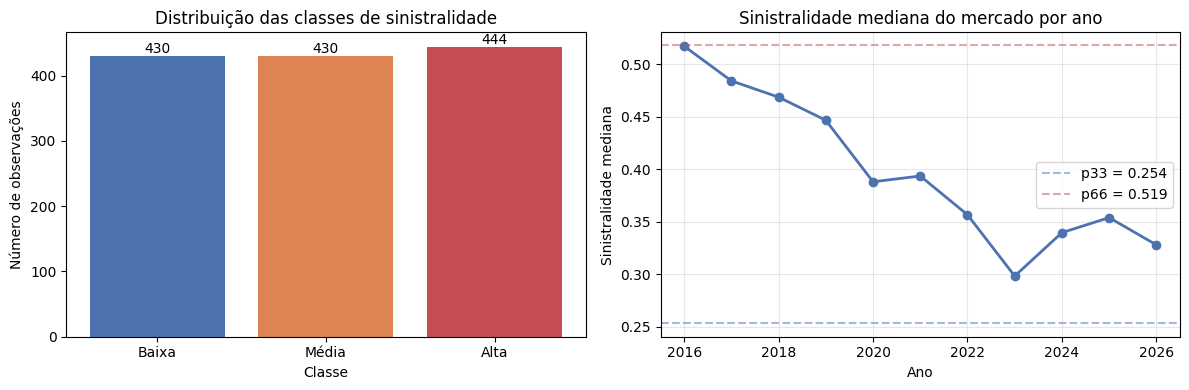

In [52]:
# Distribuição do target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: contagem por classe
contagem = dataset["target"].value_counts().sort_index()
nomes = {0: "Baixa", 1: "Média", 2: "Alta"}
cores = ["#4C72B0", "#DD8452", "#C44E52"]
axes[0].bar([nomes[i] for i in contagem.index], contagem.values, color=cores)
axes[0].set_title("Distribuição das classes de sinistralidade")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Número de observações")
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=10)

# Gráfico 2: sinistralidade por ano
sin_ano = dataset.groupby("ano")["sinistralidade"].median()
axes[1].plot(sin_ano.index, sin_ano.values, marker="o", color="#4C72B0", linewidth=2)
axes[1].axhline(P33, linestyle="--", color="#4C72B0", alpha=0.5, label=f"p33 = {P33:.3f}")
axes[1].axhline(P66, linestyle="--", color="#C44E52", alpha=0.5, label=f"p66 = {P66:.3f}")
axes[1].set_title("Sinistralidade mediana do mercado por ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Sinistralidade mediana")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


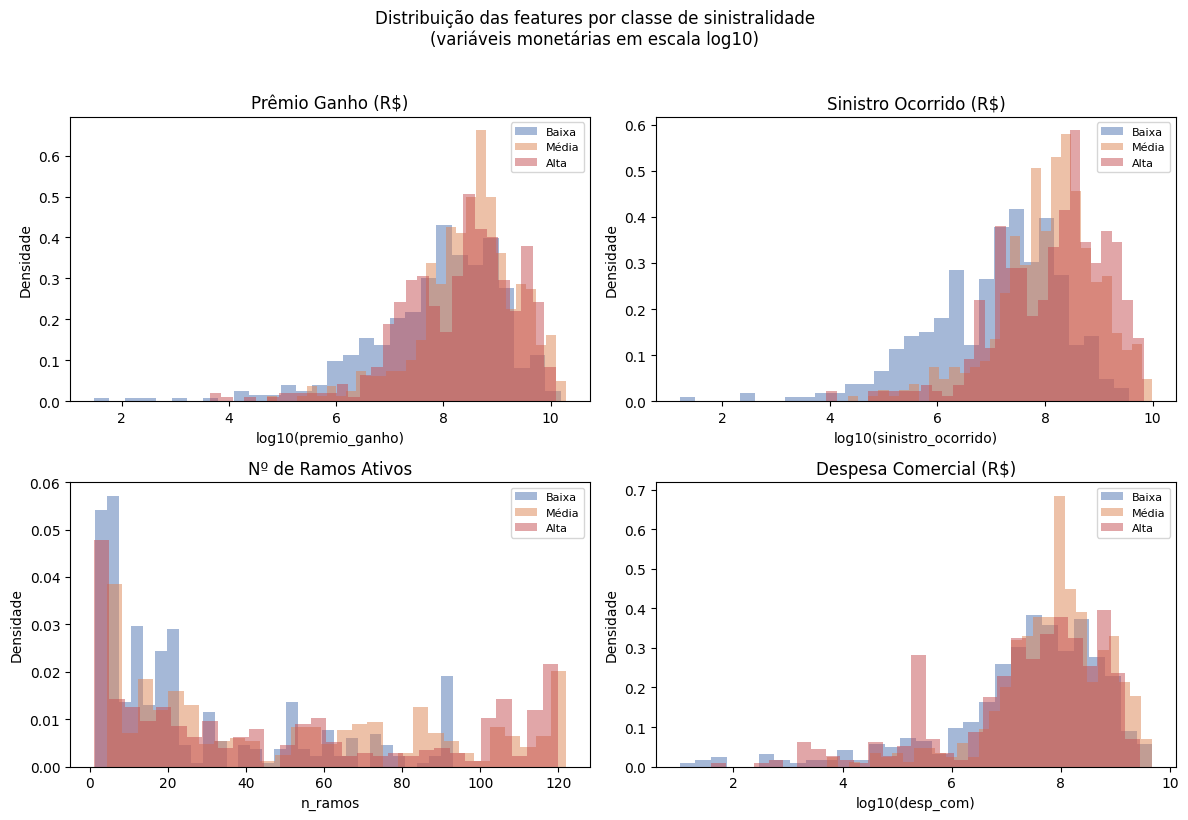

In [53]:
# Distribuição das feDD8452", "#C44E52"]
axes[0].bar([nomes[i] for i in contagem.index], contagem.values, color=cores)
axes[0].set_title("Disatures por classe
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features_plot  = ["premio_ganho", "sinistro_ocorrido", "n_ramos", "desp_com"]
titulos        = ["Prêmio Ganho (R$)", "Sinistro Ocorrido (R$)", "Nº de Ramos Ativos", "Despesa Comercial (R$)"]
# Features monetárias (escala muito grande e assimétrica) usam escala log
usa_log        = [True, True, False, True]
nomes_classe   = {0: "Baixa", 1: "Média", 2: "Alta"}

for ax, feat, titulo, log in zip(axes.flatten(), features_plot, titulos, usa_log):
    for cod, cor in zip([0, 1, 2], cores):
        dados = dataset.loc[dataset["target"] == cod, feat]

        # Remover zeros e negativos antes de plotar (não informativos para distribuição)
        dados = dados[dados > 0]
        if len(dados) == 0:
            continue

        if log:
            # Escala logarítmica: transforma os dados para log10 e plota
            import numpy as np
            dados_log = np.log10(dados)
            ax.hist(dados_log, bins=30, alpha=0.5,
                    label=nomes_classe[cod], color=cor, density=True)
            ax.set_xlabel(f"log10({feat})")
        else:
            # Escala linear com clip nos percentis 5-95 (apenas para n_ramos)
            lo, hi = dados.quantile(0.05), dados.quantile(0.95)
            if lo < hi:
                dados = dados.clip(lo, hi)
            ax.hist(dados, bins=30, alpha=0.5,
                    label=nomes_classe[cod], color=cor, density=True)
            ax.set_xlabel(feat)

    ax.set_title(titulo)
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=8)

plt.suptitle("Distribuição das features por classe de sinistralidade\n(variáveis monetárias em escala log10)", y=1.02)
plt.tight_layout()
plt.show()


## 5. Modelagem

### 5.1 Separação em treino e teste (holdout)

Foram separamos 80% dos dados para treino
e 20% para teste final, com normalização via `StandardScaler` — necessária para
os algoritmos sensíveis à escala (KNN e SVM).

As features utilizadas são: `premio_ganho`, `sinistro_ocorrido`, `n_ramos`, `desp_com`.
A `sinistralidade` **não entra como feature**.
O `plajustado` também não entra pois, como verificado na análise exploratória, o PL
isolado não é preditor relevante da faixa de sinistralidade (correlação ≈ -0,05).


In [54]:
# === Separação em treino e teste ===
FEATURES = ["premio_ganho", "sinistro_ocorrido", "n_ramos", "desp_com"]
TARGET   = "target"

array    = dataset[FEATURES + [TARGET]].values
X        = array[:, :-1]   # features
y        = array[:, -1].astype(int)   # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=7
)

# Normalização (ajuste apenas no treino, aplicação no teste)
scaler   = StandardScaler()
X_train  = scaler.fit_transform(X_train)
X_test   = scaler.transform(X_test)

print(f"Treino : {X_train.shape} | Classe positiva: {np.bincount(y_train.astype(int))}")
print(f"Teste  : {X_test.shape}  | Classe positiva: {np.bincount(y_test.astype(int))}")


Treino : (1043, 4) | Classe positiva: [341 340 362]
Teste  : (261, 4)  | Classe positiva: [89 90 82]


### 5.2 Validação cruzada (10-fold)

Seguindo exatamente a estrutura do notebook de aula: KFold com 10 partições,
comparando KNN, CART, Naive Bayes e SVM via acurácia média ± desvio padrão.


Resultados da Validação Cruzada (10-fold):

KNN  : 0.6970 (+/- 0.0361)
CART : 0.7977 (+/- 0.0428)
NB   : 0.4506 (+/- 0.0321)
SVM  : 0.6011 (+/- 0.0384)


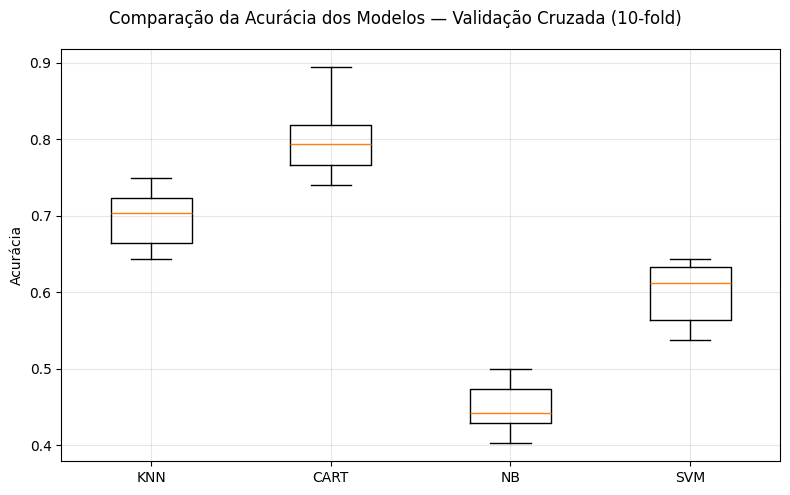

In [55]:
# === Validação cruzada ===
np.random.seed(7)

# Criando os folds
num_particoes = 10
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7)

# Definindo os modelos
models  = []
results = []
names   = []

models.append(("KNN",  KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier()))
models.append(("NB",   GaussianNB()))
models.append(("SVM",  SVC()))

# Avaliando cada modelo
print("Resultados da Validação Cruzada (10-fold):\n")
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")
    results.append(cv_results)
    names.append(name)
    msg = f"{name4:5s}: {cv_results.mean():.4f} (+/- {cv_results.std():.4f})"
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(8, 5))
fig.suptitle("Comparação da Acurácia dos Modelos — Validação Cruzada (10-fold)")
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
ax.set_ylabel("Acurácia")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Avaliação final no conjunto de teste

O modelo com melhor desempenho médio na validação cruzada (CART) é treinado
com todo o conjunto de treino e avaliado no conjunto de teste — dados que **não
foram vistos** durante o treinamento nem a validação cruzada.


In [56]:
# === Treinamento final com CART (melhor modelo na validação cruzada) ===
modelo_final = DecisionTreeClassifier(random_state=7)
modelo_final.fit(X_train, y_train)

predicoes = modelo_final.predict(X_test)

# Acurácia geral
acc = accuracy_score(y_test, predicoes)
print(f"Acurácia no conjunto de teste: {acc:.4f} ({acc*100:.1f}%)\n")

# Relatório completo por classe
print("Relatório de classificação:")
print(classification_report(
    y_test, predicoes,
    target_names=["Baixa (0)", "Média (1)", "Alta (2)"]
))


Acurácia no conjunto de teste: 0.8084 (80.8%)

Relatório de classificação:
              precision    recall  f1-score   support

   Baixa (0)       0.89      0.83      0.86        89
   Média (1)       0.72      0.72      0.72        90
    Alta (2)       0.82      0.88      0.85        82

    accuracy                           0.81       261
   macro avg       0.81      0.81      0.81       261
weighted avg       0.81      0.81      0.81       261



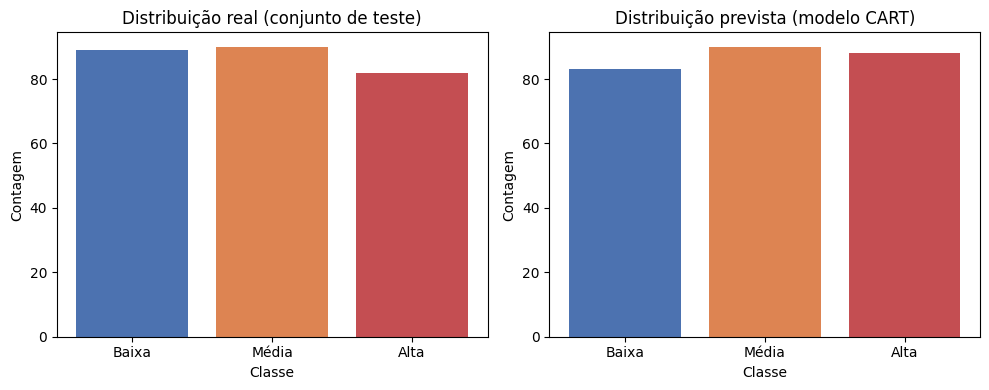

In [57]:
# Comparação visual: distribuição real vs. prevista
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Real
contagem_real = pd.Series(y_test).value_counts().sort_index()
axes[0].bar([nomes_classe[i] for i in contagem_real.index], contagem_real.values, color=cores)
axes[0].set_title("Distribuição real (conjunto de teste)")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Contagem")

# Prevista
contagem_prev = pd.Series(predicoes).value_counts().sort_index()
axes[1].bar([nomes_classe[i] for i in contagem_prev.index], contagem_prev.values, color=cores)
axes[1].set_title("Distribuição prevista (modelo CART)")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Contagem")

plt.tight_layout()
plt.show()


## 7. Evolução da sinistralidade ao longo do período (2016–2026)

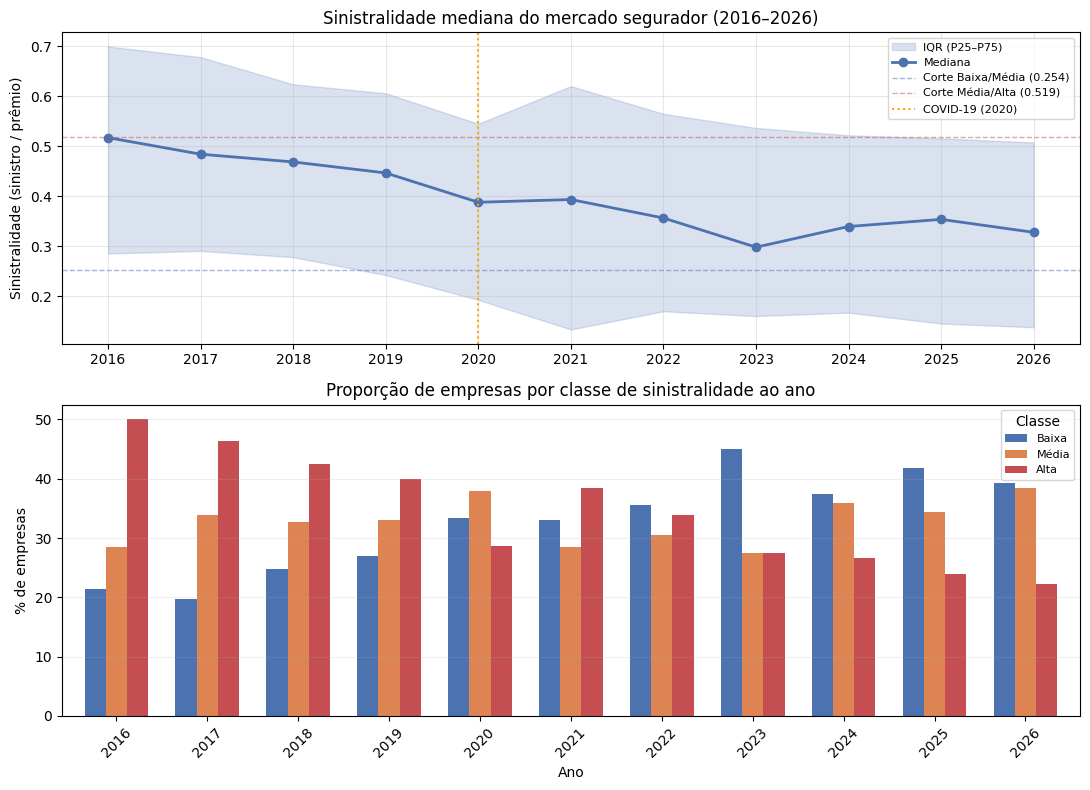


Proporção por classe (%) a cada ano:


,Baixa,Média,Alta
ano,,,
2016,21.4,28.6,50.0
2017,19.6,33.9,46.4
2018,24.8,32.7,42.5
2019,27.0,33.0,40.0
2020,33.3,38.0,28.7
2021,33.0,28.6,38.4
2022,35.7,30.4,33.9
2023,45.0,27.5,27.5
2024,37.5,35.9,26.6


In [58]:
# Taxa de cada classe por ano
sin_ano_class = dataset.groupby(["ano", "target"]).size().unstack(fill_value=0)
sin_ano_class.columns = [nomes_classe[c] for c in sin_ano_class.columns]
sin_ano_pct = sin_ano_class.div(sin_ano_class.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(11, 8))

# Gráfico 1: sinistralidade mediana do mercado por ano
sin_mediana = dataset.groupby("ano")["sinistralidade"].agg(
    mediana="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75)
)
axes[0].fill_between(sin_mediana.index, sin_mediana["p25"], sin_mediana["p75"],
                     alpha=0.2, color="#4C72B0", label="IQR (P25–P75)")
axes[0].plot(sin_mediana.index, sin_mediana["mediana"],
             color="#4C72B0", linewidth=2, marker="o", label="Mediana")
axes[0].axhline(P33, linestyle="--", color="#4C72B0", alpha=0.5, linewidth=1, label=f"Corte Baixa/Média ({P33:.3f})")
axes[0].axhline(P66, linestyle="--", color="#C44E52", alpha=0.5, linewidth=1, label=f"Corte Média/Alta ({P66:.3f})")
axes[0].axvline(2020, linestyle=":", color="orange", linewidth=1.5, label="COVID-19 (2020)")
axes[0].set_title("Sinistralidade mediana do mercado segurador (2016–2026)")
axes[0].set_ylabel("Sinistralidade (sinistro / prêmio)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(sin_mediana.index)

# Gráfico 2: proporção de empresas em cada classe por ano
sin_ano_pct.plot(kind="bar", ax=axes[1], color=cores, width=0.7)
axes[1].set_title("Proporção de empresas por classe de sinistralidade ao ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("% de empresas")
axes[1].legend(title="Classe", fontsize=8)
axes[1].set_xticklabels(sin_ano_pct.index, rotation=45)
axes[1].grid(alpha=0.2, axis="y")

plt.tight_layout()
plt.show()

# Tabela resumo
print("\nProporção por classe (%) a cada ano:")
display(sin_ano_pct.round(1))

## 8. Conclusão

**Objetivo do Trabalho e Alinhamento ao Problema**  
Este MVP teve como objetivo construir e avaliar modelos de ML capazes de mitigar riscos no mercado segurador ao classificar empresas em faixas de risco de sinistralidade (Baixa, Média e Alta). O grande desafio de negócio foi realizar essa previsão utilizando apenas dados brutos de receita estrutural, volume de indenizações e despesas comerciais, removendo a própria taxa de sinistralidade calculada para simular um cenário preditivo real e livre de vazamento de dados (*data leakage*).

**Melhor Solução Encontrada e Comparação com o Baseline**  
O modelo baseado em Árvore de Decisão (CART) foi a melhor solução encontrada, atingindo uma acurácia de 80,84% no conjunto de teste final. Na etapa de validação cruzada (10-fold), o CART já havia demonstrado superioridade com uma acurácia média de 79,77% (+/- 0,0428). Esse resultado superou expressivamente o *baseline* ingênuo/aleatório de um problema de 3 classes (~33,3%) e o modelo probabilístico Naive Bayes, que performou próximo ao acaso com 45,06% de acurácia. O CART também se mostrou mais competitivo que o KNN (69,70%) e o SVM (60,11%).

**Principais Aprendizados**  
O excelente desempenho do modelo CART confirmou a hipótese inicial de que algoritmos baseados em árvores são altamente eficazes para este problema. Como o *target* foi criado a partir de cortes rígidos de percentis (33 e 66), a dinâmica de divisões ortogonais da árvore conseguiu rastrear perfeitamente as fronteiras de decisão no espaço de variáveis. O relatório de classificação provou que o modelo é extremamente robusto para identificar os extremos de risco, alcançando um F1-Score de 0,86 para a faixa Baixa** e **0,85 para a faixa Alta.

**Limitações**  
Apesar do sucesso, a principal limitação do modelo CART puro é a instabilidade inerente de árvores de decisão individuais (variância), o que pode ser observado no desvio padrão de ~4,2% durante os testes cruzados. Além disso, a faixa "Média" apresentou um desempenho ligeiramente inferior (F1-score de 0,72), indicando que empresas com comportamento intermediário possuem dados operacionais sobrepostos, tornando a separação matemática mais complexa nessa zona central.

**Próximos Passos**  
Como evolução do MVP para um ambiente de produção, recomendam-se os seguintes passos:
1. **Modelos de Ensemble:** Implementar algoritmos de florestas ou com técnica de *boosting* (como Random Forest ou XGBoost) para reduzir a variância do CART e aumentar a generalização.
2. **Engenharia de Features:** Criar novas variáveis macroeconômicas ou indicadores de crescimento anualizado (ex: crescimento percentual de prêmios de um ano para o outro).
3. **Abordagem Temporal:** Testar uma separação de treino e teste baseada em blocos de tempo (*Time Series Split*) em vez do Holdout aleatório, validando a eficácia do modelo para prever a sinistralidade técnica de anos futuros.